In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 5)

In [2]:
df = pd.read_csv("../data/processed_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print("Shape before feature engineering:", df.shape)
df.head()

Shape before feature engineering: (1486, 5)


,Close,High,Low,Open,Volume
Date,,,,,
2020-01-01,675.324158,683.152852,673.490062,679.081936,14004468
2020-01-02,686.821228,689.348791,676.397899,676.397899,17710316
2020-01-03,687.648804,689.661895,681.318729,685.792252,20984698
2020-01-06,671.700623,683.510705,670.134872,679.976657,24519177
2020-01-07,682.034546,686.463335,677.068889,679.529321,16683622


In [3]:
# 7-day and 21-day Simple Moving Average
df['MA7']  = df['Close'].rolling(window=7).mean()
df['MA21'] = df['Close'].rolling(window=21).mean()

print("MA7 and MA21 created ✅")

MA7 and MA21 created ✅


In [4]:
# Daily return (% change)
df['Daily_Return'] = df['Close'].pct_change() * 100

# Volatility — rolling standard deviation of returns (7 days)
df['Volatility'] = df['Daily_Return'].rolling(window=7).std()

print("Daily Return and Volatility created ✅")

Daily Return and Volatility created ✅


In [5]:
# Price range = difference between High and Low each day
df['Price_Range'] = df['High'] - df['Low']

# Momentum = current close minus close 10 days ago
df['Momentum'] = df['Close'] - df['Close'].shift(10)

print("Price Range and Momentum created ✅")

Price Range and Momentum created ✅


In [6]:
# RSI tells us if a stock is overbought (>70) or oversold (<30)
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.where(delta > 0, 0)
    loss  = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs  = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = calculate_rsi(df['Close'])
print("RSI created ✅")

# Quick check
print(f"\nRSI range: {df['RSI'].min():.2f} to {df['RSI'].max():.2f}")
print(f"Days overbought (RSI > 70) : {(df['RSI'] > 70).sum()}")
print(f"Days oversold  (RSI < 30)  : {(df['RSI'] < 30).sum()}")

RSI created ✅

RSI range: 7.72 to 97.56
Days overbought (RSI > 70) : 273
Days oversold  (RSI < 30)  : 153


In [7]:
# Target: 1 if next day close is HIGHER than today, else 0
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

print("Target column created ✅")
print(f"\nTarget distribution:")
print(df['Target'].value_counts())
print(f"\nUp days   : {df['Target'].sum()} ({df['Target'].mean()*100:.1f}%)")
print(f"Down days : {(df['Target']==0).sum()} ({(1-df['Target'].mean())*100:.1f}%)")

Target column created ✅

Target distribution:
Target
1    771
0    715
Name: count, dtype: int64

Up days   : 771 (51.9%)
Down days : 715 (48.1%)


In [8]:
# Some rows will have NaN because of rolling calculations
print("Rows before dropping NaN:", len(df))

df.dropna(inplace=True)

print("Rows after  dropping NaN:", len(df))
print("Rows removed:", 1257 - len(df))

Rows before dropping NaN: 1486
Rows after  dropping NaN: 1466
Rows removed: -209


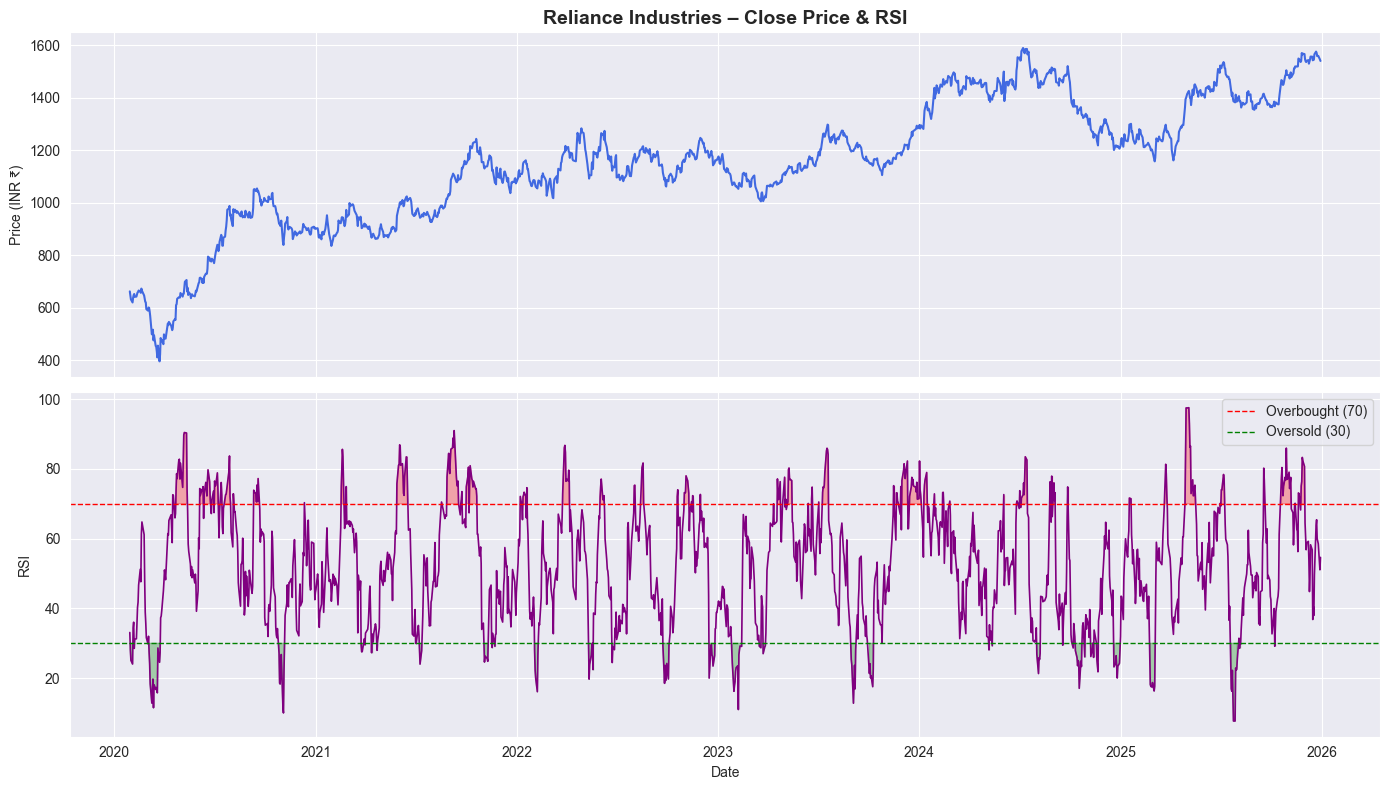

RSI chart saved!


In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Close price
ax1.plot(df.index, df['Close'], color='royalblue', linewidth=1.5)
ax1.set_title('Reliance Industries – Close Price & RSI', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (INR ₹)')

# RSI
ax2.plot(df.index, df['RSI'], color='purple', linewidth=1.2)
ax2.axhline(y=70, color='red',   linestyle='--', linewidth=1, label='Overbought (70)')
ax2.axhline(y=30, color='green', linestyle='--', linewidth=1, label='Oversold (30)')
ax2.fill_between(df.index, df['RSI'], 70,
                  where=(df['RSI'] >= 70), alpha=0.3, color='red')
ax2.fill_between(df.index, df['RSI'], 30,
                  where=(df['RSI'] <= 30), alpha=0.3, color='green')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.savefig('../data/chart6_rsi.png', dpi=150)
plt.show()
print("RSI chart saved!")

In [10]:
print("All features created:")
print(df.columns.tolist())
print("\nShape:", df.shape)
print("\nSample data:")
df.head()

All features created:
['Close', 'High', 'Low', 'Open', 'Volume', 'MA7', 'MA21', 'Daily_Return', 'Volatility', 'Price_Range', 'Momentum', 'RSI', 'Target']

Shape: (1466, 13)

Sample data:


,Close,High,Low,Open,Volume,MA7,MA21,Daily_Return,Volatility,Price_Range,Momentum,RSI,Target
Date,,,,,,,,,,,,,
2020-01-29,662.015503,668.524454,654.947287,659.420810,24746565,675.746033,682.510643,0.550371,0.932805,13.577167,-19.683472,33.110325,0
2020-01-30,645.866089,661.948423,644.188533,661.635285,22402689,669.984776,681.107878,-2.439431,1.135354,17.759891,-42.118164,28.126381,0
2020-01-31,631.506104,650.116002,629.515409,650.004137,34750310,662.207223,678.473825,-2.223369,1.172447,20.600593,-75.759216,25.145938,0
2020-02-03,619.807739,626.272016,609.764680,612.829051,30712290,653.173889,675.243298,-1.852455,1.145263,16.507337,-65.693787,24.072101,1
2020-02-04,638.104431,640.833267,625.310140,626.294289,25383901,647.093087,673.643479,2.951995,1.998541,15.523127,-48.090454,34.425462,1


In [11]:
df.to_csv("../data/processed_data.csv", index=True)
print("✅ Feature engineered data saved to processed_data.csv")
print(f"Final dataset: {df.shape[0]} rows × {df.shape[1]} columns")

✅ Feature engineered data saved to processed_data.csv
Final dataset: 1466 rows × 13 columns
